In [1]:
import torch
import pickle
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import selfies as sf
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
from rdkit import Chem
from rdkit.Chem import Draw, AllChem, DataStructs, rdmolops, Descriptors, rdMolDescriptors, QED
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import math
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
from sklearn.metrics import r2_score
from IPython.display import display
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.utils import to_dense_batch, to_dense_adj
from torch_geometric.loader import DataLoader
import seaborn as sns
import os
import re
import sascorer
torch.cuda.empty_cache()

In [2]:
df = pd.read_csv('/Users/mateusz/Documents/apki/Graph-Latent-Space/data/raw/smiles_selfies_full.csv')

In [3]:
df.head()

,smiles,selfies
0,O=S(O)c1cc2c(cc1F)OC(c1ccc(F)cc1F)(c1ccc(F)cc1...,[O][=S][Branch1][C][O][C][=C][C][=C][Branch1][...
1,CN(C)Cc1cccc(C2Nc3cccc4c(=O)[nH]nc(c34)C2c2ccc...,[C][N][Branch1][C][C][C][C][=C][C][=C][C][Bran...
2,O=C(N[C@@H](CO)c1nc2cc(Cl)ccc2[nH]1)c1ccc(C(=O...,[O][=C][Branch2][Ring1][#Branch1][N][C@@H1][Br...
3,O=C(Cn1cc(I)cn1)N1CCCc2c1cnn2-c1ccc(F)cc1,[O][=C][Branch1][N][C][N][C][=C][Branch1][C][I...
4,Cc1ccc(-c2ccnc(Cl)c2)n1CC(=O)OCc1ccccc1,[C][C][=C][C][=C][Branch1][N][C][=C][C][=N][C]...


In [4]:
# convert to graphs
SUPPORTED_ATOMS = [1, 6, 7, 8, 9, 15, 16, 17, 35, 53]

def atom_to_feature_vector(atom):
    """zamienia atom na wektor cech, ten wektor będzie potem nodem w grafie"""
    atomic_num = atom.GetAtomicNum()
    # one hot encoding
    return [1 if atomic_num == atom_type else 0 for atom_type in SUPPORTED_ATOMS]

def smiles_to_graph(smiles_str):
    mol = Chem.MolFromSmiles(smiles_str)
    if mol is None:
        return None
    
    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append(atom_to_feature_vector(atom))
    x = torch.tensor(atom_features, dtype=torch.float)

    edges = []
    for bond in mol.GetBonds():
        edges.append((bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()))
        edges.append((bond.GetEndAtomIdx(), bond.GetBeginAtomIdx()))
    
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    data = Data(x=x, edge_index=edge_index)
    return data
    

In [5]:
smiles = "CC(CC)O" 
graph = smiles_to_graph(smiles)
print(graph)
print(graph.x)
print(graph.edge_index)

Data(x=[5, 10], edge_index=[2, 8])
tensor([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]])
tensor([[0, 1, 1, 2, 2, 3, 1, 4],
        [1, 0, 2, 1, 3, 2, 4, 1]])


In [6]:
GRAPH_PATH = '/Users/mateusz/Documents/apki/Graph-Latent-Space/data/processed/graphs.pt'

if os.path.exists(GRAPH_PATH):
    graph_list = torch.load(GRAPH_PATH)
else:
    graph_list = []
    for index, row in tqdm(df.iterrows(), total=len(df)):
        smiles = row['smiles']
        graph = smiles_to_graph(smiles)
        graph_list.append(graph)
    torch.save(graph_list, GRAPH_PATH)

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL torch_geometric.data.data.DataEdgeAttr was not an allowed global by default. Please use `torch.serialization.add_safe_globals([torch_geometric.data.data.DataEdgeAttr])` or the `torch.serialization.safe_globals([torch_geometric.data.data.DataEdgeAttr])` context manager to allowlist this global if you trust this class/function.

Check the documentat

In [62]:
# split dataset
graph_train, graph_temp = train_test_split(graph_list, test_size=0.2, random_state=42, shuffle=True)
graph_val, graph_test = train_test_split(graph_temp, test_size=0.5, random_state=42, shuffle=True)

class GraphDataset(Dataset):
    def __init__(self, graph_list):
        self.graphs = graph_list

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, index):
        return self.graphs[index]

train_dataset = GraphDataset(graph_train)
val_dataset = GraphDataset(graph_val)
test_dataset = GraphDataset(graph_test)

In [ ]:
# model
class GraphVAE(nn.Module):
    def __init__(self, latent_dim, max_nodes=37, in_channels=10, hidden_dim=256):
        super().__init__()
        self.latent_dim = latent_dim
        self.max_nodes = max_nodes
        self.in_channels = in_channels
        self.hidden_dim = hidden_dim

        # Encoder
        self.conv1 = GCNConv(in_channels, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)

        # Latent space
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder to nodes
        self.decoder_node_mlp = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, max_nodes * in_channels)
        )

        # Decoder to edges
        self.decoder_adj_mlp = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, max_nodes * max_nodes)
        )
    
    def encode(self, x, edge_index, batch):
        h = self.conv1(x, edge_index).relu()
        h = self.conv2(h, edge_index).relu()
        h_graph = global_mean_pool(h, batch)
        
        mu = self.fc_mu(h_graph)
        logvar = self.fc_logvar(h_graph)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu
    
    def decode(self, z):
        h = self.decoder_fc(z)
        
        recon_x = self.decoder_node(h).view(-1, self.max_nodes, self.in_channels)
        recon_adj = self.decoder_adj(h).view(-1, self.max_nodes, self.max_nodes)
        recon_adj = (recon_adj + recon_adj.transpose(1, 2)) / 2.0
        recon_adj = torch.sigmoid(recon_adj)
        
        return recon_x, recon_adj
    
    def forward(self, x, edge_index, batch):
        mu, logvar = self.encode(x, edge_index, batch)
        z = self.reparameterize(mu, logvar)
        recon_x, recon_adj = self.decode(z)

        # padding to max_nodes
        true_x, _ = to_dense_batch(x, batch, max_num_nodes=self.max_nodes)
        true_adj = to_dense_adj(edge_index, batch, max_num_nodes=self.max_nodes)

        return recon_x, recon_adj, true_x, true_adj, mu, logvar

def vae_graph_loss(recon_x, recon_adj, true_x, true_adj, mu, logvar, beta=0.01, edge_weight=1.0):
    in_channels = true_x.size(-1)
    logits = recon_x.reshape(-1, in_channels)
    targets = true_x.argmax(dim=-1).reshape(-1)

    # loss for atoms
    atom_loss = F.cross_entropy(logits, targets)

    # loss for edges
    edge_loss = F.binary_cross_entropy(recon_adj.reshape(-1), true_adj.reshape(-1))

    recon_loss = atom_loss + edge_weight * edge_loss

    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = recon_loss + beta * kl

    return total_loss, atom_loss.item(), edge_loss.item(), kl.item()



In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

In [ ]:
# training
latent_dim = 64
max_nodes = 37
in_channels = 10
model = GraphVAE(latent_dim, max_nodes=max_nodes, in_channels=in_channels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

beta = 0.01
edge_weight = 1.0
num_epochs = 10
history = {'train_loss': [], 'atom_loss': [], 'edge_loss': [], 'kl_loss': [], 'val_loss': []}
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

best_val_loss = float('inf')

for epoch in range(1, num_epochs + 1):
    model.train()
    total_loss = 0
    total_atom_loss = 0
    total_edge_loss = 0
    total_kl_loss = 0
    pbar = tqdm(train_loader)
    for graph in pbar:
        x, edge_index, batch = graph.x.to(device), graph.edge_index.to(device), graph.batch.to(device)

        optimizer.zero_grad()

        recon_x, recon_adj, true_x, true_adj, mu, logvar = model(x, edge_index, batch)

        loss, atom_l, edge_l, kl_l = vae_graph_loss(
            recon_x, recon_adj, true_x, true_adj, mu, logvar, beta=beta, edge_weight=edge_weight
        )
        loss.backward()
        optimizer.step()

        pbar.set_postfix({
            "atom": f"{atom_l:.3f}",
            "edge": f"{edge_l:.3f}",
            "kl": f"{kl_l:.3f}",
            "tot": f"{loss.item():.3f}",
        })

        total_loss += loss.item()
        total_atom_loss += atom_l
        total_edge_loss += edge_l
        total_kl_loss += kl_l

    with torch.no_grad():
        model.eval()
        val_loss = 0
        for graph in val_loader:
            x, edge_index, batch = graph.x.to(device), graph.edge_index.to(device), graph.batch.to(device)
            recon_x, recon_adj, true_x, true_adj, mu, logvar = model(x, edge_index, batch)

            loss, _, _, _ = vae_graph_loss(
                recon_x, recon_adj, true_x, true_adj, mu, logvar, beta=beta, edge_weight=edge_weight
            )
            val_loss += loss.item()

    total_loss /= len(train_loader)
    total_atom_loss /= len(train_loader)
    total_edge_loss /= len(train_loader)
    total_kl_loss /= len(train_loader)
    val_loss /= len(val_loader)

    if val_loss < best_val_loss:
        MODEL_PATH = '/content/best_graph_vae.pt'
        torch.save(model.state_dict(), MODEL_PATH)
        best_val_loss = val_loss

    history['train_loss'].append(total_loss)
    history['atom_loss'].append(total_atom_loss)
    history['edge_loss'].append(total_edge_loss)
    history['kl_loss'].append(total_kl_loss)
    history['val_loss'].append(val_loss)
    print(f"Epoch {epoch}/{num_epochs} - Train Loss: {total_loss:.4f} (Atom: {total_atom_loss:.4f}, Edge: {total_edge_loss:.4f}, KL: {total_kl_loss:.4f}) - Val Loss: {val_loss:.4f}")

  0%|          | 0/19861 [00:00<?, ?it/s]

Epoch 1/50 - Train Loss: 0.7787 (Atom: 0.7021, Edge: 0.0646, KL: 1.1992) - Val Loss: 0.7220


  0%|          | 0/19861 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [92]:
# loading model (run if trained before)
latent_dim = 64
max_nodes = 37
in_channels = 10
node_emb_dim = 64

model = GraphVAE_GNN_Decoder(latent_dim, max_nodes=max_nodes, in_channels=in_channels, node_emb_dim=node_emb_dim).to(device)
MODEL_PATH = '/Users/mateusz/Documents/apki/Graph-Latent-Space/models/best_graph_vae_gnn_decoder_no_weights.pt'

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print("Model loaded succesfully")
else:
    print(f"ERROR: File {MODEL_PATH} does not exist")

Model loaded succesfully


In [85]:
# loading model (run if trained before)
latent_dim = 64
max_nodes = 37
in_channels = 10

model = GraphVAE_GNN_Decoder(latent_dim, max_nodes=max_nodes, in_channels=in_channels).to(device)
MODEL_PATH = '/Users/mateusz/Documents/apki/Graph-Latent-Space/models/best_graph_vae_gnn_decoder.pt'

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print("Model loaded succesfully")
else:
    print(f"ERROR: File {MODEL_PATH} does not exist")

Model loaded succesfully


In [93]:
# utils
def get_molecule_properties(mol):
    return {
        "molWt": Descriptors.MolWt(mol),
        "HeavyAtomCount": mol.GetNumHeavyAtoms(),
        "cLogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "NumRotatableBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "RingCount": rdMolDescriptors.CalcNumRings(mol),
        "AromaticRingCount": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "NumSpiroAtoms": rdMolDescriptors.CalcNumSpiroAtoms(mol),
        "NumBridgeheadAtoms": rdMolDescriptors.CalcNumBridgeheadAtoms(mol),
        "BertzCT": Descriptors.BertzCT(mol),
        "QED": QED.qed(mol),
        "SA-score": sascorer.calculateScore(mol)
    }

def compute_property(mol, name):
    if name == "molWt":
        return Descriptors.MolWt(mol)
    elif name == "HeavyAtomCount":
        return mol.GetNumHeavyAtoms()
    elif name == "cLogP":
        return Descriptors.MolLogP(mol)
    elif name == "TPSA":
        return Descriptors.TPSA(mol)
    elif name == "HBD":
        return rdMolDescriptors.CalcNumHBD(mol)
    elif name == "HBA":
        return rdMolDescriptors.CalcNumHBA(mol)
    elif name == "NumRotatableBonds":
        return rdMolDescriptors.CalcNumRotatableBonds(mol)
    elif name == "RingCount":
        return rdMolDescriptors.CalcNumRings(mol)
    elif name == "AromaticRingCount":
        return rdMolDescriptors.CalcNumAromaticRings(mol)
    elif name == "FractionCSP3":
        return rdMolDescriptors.CalcFractionCSP3(mol)
    elif name == "NumSpiroAtoms":
        return rdMolDescriptors.CalcNumSpiroAtoms(mol)
    elif name == "NumBridgeheadAtoms":
        return rdMolDescriptors.CalcNumBridgeheadAtoms(mol)
    elif name == "BertzCT":
        return Descriptors.BertzCT(mol)
    elif name == "QED":
        return QED.qed(mol)
    elif name == "SA-score":
        return sascorer.calculateScore(mol)
    else:
        return np.nan

def latents_to_mol(model, z, edge_threshold=0.5):
    """
    GraphVAE latent -> RDKit Mol

    Zwraca listę:
        [Mol, Mol, None, Mol, ...]
    """

    model.eval()

    with torch.no_grad():
        recon_x, recon_adj = model.decode(z)

    recon_x = recon_x.cpu()
    recon_adj = recon_adj.cpu()

    mols = []

    for sample_idx in range(z.size(0)):

        atom_logits = recon_x[sample_idx]
        adj = recon_adj[sample_idx]

        atom_classes = atom_logits.argmax(dim=-1).numpy()

        adj = adj.numpy()

        # wymuszamy symetrię
        adj = (adj + adj.T) / 2

        # binary adjacency
        adj = (adj > edge_threshold).astype(np.int32)

        np.fill_diagonal(adj, 0)

        # usuwamy izolowane nody (padding modelu)
        active_nodes = np.where(adj.sum(axis=1) > 0)[0]

        if len(active_nodes) == 0:
            mols.append(None)
            continue

        rw_mol = Chem.RWMol()

        node_map = {}

        # dodawanie atomów
        for old_idx in active_nodes:

            atom_class = atom_classes[old_idx]

            atomic_num = SUPPORTED_ATOMS[atom_class]

            new_idx = rw_mol.AddAtom(
                Chem.Atom(int(atomic_num))
            )

            node_map[old_idx] = new_idx

        # dodawanie wiązań
        for i in active_nodes:
            for j in active_nodes:

                if j <= i:
                    continue

                if adj[i, j] == 1:

                    try:
                        rw_mol.AddBond(
                            node_map[i],
                            node_map[j],
                            Chem.BondType.SINGLE
                        )
                    except:
                        pass

        try:

            mol = rw_mol.GetMol()

            Chem.SanitizeMol(mol)

            mols.append(mol)

        except:
            mols.append(None)

    return mols

In [11]:
def latents_to_mol(model, z, edge_threshold=0.9):
    """
    GraphVAE_2 latent -> RDKit Mol
    Dostosowane do surowych logitów zwracanych przez nowy dekoder.
    """
    model.eval()

    with torch.no_grad():
        recon_x, recon_adj = model.decode(z)
        
        # NOWOŚĆ: Nakładamy sigmoid na krawędzie, bo model wypluwa surowe logity!
        recon_adj = torch.sigmoid(recon_adj)

    recon_x = recon_x.cpu()
    recon_adj = recon_adj.cpu()

    mols = []

    for sample_idx in range(z.size(0)):
        atom_logits = recon_x[sample_idx]
        adj = recon_adj[sample_idx]

        # Wybieramy atomy przez argmax (to zostaje bez zmian)
        atom_classes = atom_logits.argmax(dim=-1).numpy()
        adj = adj.numpy()

        # Wymuszamy symetrię na prawdopodobieństwach
        adj = (adj + adj.T) / 2

        # Binary adjacency na bazie nowego progu (np. > 0.9)
        adj = (adj > edge_threshold).astype(np.int32)
        np.fill_diagonal(adj, 0)

        # Usuwamy izolowane nody (padding modelu)
        active_nodes = np.where(adj.sum(axis=1) > 0)[0]

        if len(active_nodes) == 0:
            mols.append(None)
            continue

        rw_mol = Chem.RWMol()
        node_map = {}

        # Dodawanie atomów ciężkich (jeśli SUPPORTED_ATOMS zawiera H pod jakimś indeksem, 
        # warto upewnić się, że RDKit nie dostanie samotnego H)
        for old_idx in active_nodes:
            atom_class = atom_classes[old_idx]
            atomic_num = SUPPORTED_ATOMS[atom_class]
            
            # Opcjonalne zabezpieczenie: jeśli model próbowałby zostawić jawny wodór jako ciężki atom
            if atomic_num == 1:
                continue

            new_idx = rw_mol.AddAtom(Chem.Atom(int(atomic_num)))
            node_map[old_idx] = new_idx

        # Dodawanie wiązań
        for i in active_nodes:
            for j in active_nodes:
                if j <= i:
                    continue

                if adj[i, j] == 1:
                    # Upewniamy się, że oba atomy zostały dodane do node_map 
                    # (zabezpieczenie przed pominiętymi wodorami/błędami indeksacji)
                    if i in node_map and j in node_map:
                        try:
                            rw_mol.AddBond(
                                node_map[i],
                                node_map[j],
                                Chem.BondType.SINGLE
                            )
                        except:
                            pass

        try:
            mol = rw_mol.GetMol()
            Chem.SanitizeMol(mol)
            mols.append(mol)
        except:
            mols.append(None)

    return mols

In [64]:
def latents_to_mol_top_n(model, z, top_k_edges=20):
    """
    Dynamiczne dekodowanie: zamiast sztywnego progu, 
    bierzemy dokładnie Top-K najsilniejszych wiązań poza przekątną.
    """
    model.eval()
    with torch.no_grad():
        recon_x, recon_adj = model.decode(z)

    recon_x = recon_x.cpu()
    recon_adj = recon_adj.cpu()
    mols = []

    for sample_idx in range(z.size(0)):
        atom_logits = recon_x[sample_idx]
        adj = recon_adj[sample_idx].numpy()

        # 1. Symetria i czyszczenie przekątnej
        adj = (adj + adj.T) / 2
        np.fill_diagonal(adj, 0)

        # 2. Wyciągamy indeksy górnego trójkąta macierzy (bez przekątnej), żeby nie dublować wiązań
        iu = np.triu_indices(adj.shape[0], k=1)
        flat_values = adj[iu]
        
        # 3. Szukamy progu odcięcia dla Top-K najwyższych wartości
        if len(flat_values) >= top_k_edges:
            # Sortujemy wartości i bierzemy tę na pozycji top_k_edges od końca
            thresh = np.partition(flat_values, -top_k_edges)[-top_k_edges]
        else:
            thresh = 0.5

        # 4. Binaryzacja na bazie dynamicznego progu
        adj_binary = (adj >= thresh).astype(np.int32)
        np.fill_diagonal(adj_binary, 0)

        # Wyciągamy tylko te nody, które dostały jakieś wiązanie
        active_nodes = np.where(adj_binary.sum(axis=1) > 0)[0]

        if len(active_nodes) == 0:
            mols.append(None)
            continue

        rw_mol = Chem.RWMol()
        node_map = {}
        atom_classes = atom_logits.argmax(dim=-1).numpy()

        for old_idx in active_nodes:
            atom_class = atom_classes[old_idx]
            atomic_num = SUPPORTED_ATOMS[atom_class]
            new_idx = rw_mol.AddAtom(Chem.Atom(int(atomic_num)))
            node_map[old_idx] = new_idx

        for i in active_nodes:
            for j in active_nodes:
                if j <= i:
                    continue
                if adj_binary[i, j] == 1 and i in node_map and j in node_map:
                    try:
                        rw_mol.AddBond(node_map[i], node_map[j], Chem.BondType.SINGLE)
                    except:
                        pass
        try:
            mol = rw_mol.GetMol()
            Chem.SanitizeMol(mol)
            mols.append(mol)
        except:
            mols.append(None)

    return mols

In [ ]:
n_samples = 20000
z = torch.randn(n_samples, latent_dim, device=device)

mols = []
for i in range(n_samples):
    # Losujemy budżet krawędzi dla każdej próbki osobo!
    # Rozkład trójkątny lub zwykły losowy sprawi, że pokryjemy całe spektrum wielkości
    random_top_k = int(np.random.randint(12, 35)) 
    
    # Próbkujemy tylko jedną cząsteczkę z danym limitem krawędzi
    single_mol = latents_to_mol_top_n(model, z[i:i+1], top_k_edges=random_top_k)
    mols.extend(single_mol)

[18:37:24] Explicit valence for atom # 0 N, 5, is greater than permitted
[18:37:24] Explicit valence for atom # 6 H, 2, is greater than permitted
[18:37:24] Explicit valence for atom # 2 O, 3, is greater than permitted
[18:37:24] Explicit valence for atom # 16 H, 2, is greater than permitted
[18:37:24] Explicit valence for atom # 1 C, 5, is greater than permitted
[18:37:24] Explicit valence for atom # 2 Br, 4, is greater than permitted
[18:37:24] Explicit valence for atom # 1 N, 5, is greater than permitted
[18:37:24] Explicit valence for atom # 17 H, 2, is greater than permitted
[18:37:24] Explicit valence for atom # 4 O, 3, is greater than permitted
[18:37:24] Explicit valence for atom # 3 O, 3, is greater than permitted
[18:37:24] Explicit valence for atom # 1 N, 4, is greater than permitted
[18:37:24] Explicit valence for atom # 0 N, 4, is greater than permitted
[18:37:24] Explicit valence for atom # 1 O, 4, is greater than permitted
[18:37:24] Explicit valence for atom # 0 C, 8, i

In [81]:
def latents_to_mol_classic_threshold(model, z, edge_threshold=0.52):
    """
    Klasyczne próbkowanie na bazie stałego progu (edge_threshold).
    Działa poprawnie z modelami typu Inner Product.
    """
    model.eval()
    with torch.no_grad():
        recon_x, recon_adj = model.decode(z)

    recon_x = recon_x.cpu()
    recon_adj = recon_adj.cpu()
    mols = []

    for sample_idx in range(z.size(0)):
        atom_logits = recon_x[sample_idx]
        adj = recon_adj[sample_idx].numpy()

        # 1. Wymuszamy symetrię macierzy
        adj = (adj + adj.T) / 2
        
        # 2. KRYTYCZNE: Zerujemy przekątną ZANIM sprawdzimy próg!
        # Dzięki temu norma wektora własnego nie oszuka walidacji
        np.fill_diagonal(adj, 0)

        # 3. Klasyczna, stała binaryzacja
        adj_binary = (adj > edge_threshold).astype(np.int32)

        # Wyciągamy tylko nody aktywne (które mają jakiekolwiek wiązanie)
        active_nodes = np.where(adj_binary.sum(axis=1) > 0)[0]

        if len(active_nodes) == 0:
            mols.append(None)
            continue

        rw_mol = Chem.RWMol()
        node_map = {}
        atom_classes = atom_logits.argmax(dim=-1).numpy()

        for old_idx in active_nodes:
            atom_class = atom_classes[old_idx]
            atomic_num = SUPPORTED_ATOMS[atom_class]
            new_idx = rw_mol.AddAtom(Chem.Atom(int(atomic_num)))
            node_map[old_idx] = new_idx

        for i in active_nodes:
            for j in active_nodes:
                if j <= i:
                    continue
                if adj_binary[i, j] == 1 and i in node_map and j in node_map:
                    try:
                        rw_mol.AddBond(node_map[i], node_map[j], Chem.BondType.SINGLE)
                    except:
                        pass
        try:
            mol = rw_mol.GetMol()
            Chem.SanitizeMol(mol)
            mols.append(mol)
        except:
            mols.append(None)

    return mols

mols = latents_to_mol_classic_threshold(model, z, edge_threshold=0.52)

[18:40:41] Explicit valence for atom # 0 N, 9, is greater than permitted
[18:40:41] Explicit valence for atom # 2 C, 5, is greater than permitted
[18:40:41] Explicit valence for atom # 0 C, 8, is greater than permitted
[18:40:41] Explicit valence for atom # 0 C, 5, is greater than permitted
[18:40:41] Explicit valence for atom # 0 N, 5, is greater than permitted
[18:40:41] Explicit valence for atom # 2 O, 5, is greater than permitted
[18:40:41] Explicit valence for atom # 0 C, 12, is greater than permitted
[18:40:41] Explicit valence for atom # 0 C, 8, is greater than permitted
[18:40:41] Explicit valence for atom # 0 N, 7, is greater than permitted
[18:40:41] Explicit valence for atom # 1 O, 4, is greater than permitted
[18:40:41] Explicit valence for atom # 0 N, 7, is greater than permitted
[18:40:41] Explicit valence for atom # 3 O, 4, is greater than permitted
[18:40:41] Explicit valence for atom # 0 C, 6, is greater than permitted
[18:40:41] Explicit valence for atom # 0 N, 7, is 

In [83]:
model.eval()
with torch.no_grad():
    recon_x, recon_adj = model.decode(z[0:1]) # bierzemy tylko pierwszy latent

adj = recon_adj[0].cpu().numpy()
adj = (adj + adj.T) / 2
np.fill_diagonal(adj, 0)

print("--- DIAGNOSTYKA WARTOŚCI MACIERZY SĄSIEDZTWA ---")
print(f"Najwyższa wartość (Max): {adj.max():.6f}")
print(f"Najniższa wartość (Min): {adj.min():.6f}")
print(f"Średnia wartość (Mean): {adj.mean():.6f}")

# Zobaczmy ile krawędzi przetrwa dla różnych progów:
for t in [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]:
    krawedzie = (adj > t).sum() // 2
    print(f"Dla progu {t}: przetrwa {krawedzie} wiązań")

--- DIAGNOSTYKA WARTOŚCI MACIERZY SĄSIEDZTWA ---
Najwyższa wartość (Max): 1.000000
Najniższa wartość (Min): 0.000000
Średnia wartość (Mean): 0.288587
Dla progu 0.1: przetrwa 283 wiązań
Dla progu 0.3: przetrwa 223 wiązań
Dla progu 0.5: przetrwa 185 wiązań
Dla progu 0.7: przetrwa 157 wiązań
Dla progu 0.9: przetrwa 129 wiązań
Dla progu 0.95: przetrwa 118 wiązań
Dla progu 0.99: przetrwa 100 wiązań


In [94]:
n_samples = 100

z = torch.randn(
    n_samples,
    latent_dim,
    device=device
)

mols = latents_to_mol(model, z, edge_threshold=0.50)

[20:35:29] Explicit valence for atom # 0 H, 36, is greater than permitted
[20:35:30] Explicit valence for atom # 0 H, 36, is greater than permitted
[20:35:30] Explicit valence for atom # 0 C, 36, is greater than permitted
[20:35:30] Explicit valence for atom # 0 C, 36, is greater than permitted
[20:35:30] Explicit valence for atom # 0 H, 36, is greater than permitted
[20:35:30] Explicit valence for atom # 0 H, 36, is greater than permitted
[20:35:30] Explicit valence for atom # 0 C, 36, is greater than permitted
[20:35:30] Explicit valence for atom # 0 C, 36, is greater than permitted
[20:35:30] Explicit valence for atom # 0 H, 36, is greater than permitted
[20:35:30] Explicit valence for atom # 0 H, 36, is greater than permitted
[20:35:30] Explicit valence for atom # 0 H, 36, is greater than permitted
[20:35:30] Explicit valence for atom # 0 H, 36, is greater than permitted
[20:35:30] Explicit valence for atom # 0 C, 36, is greater than permitted
[20:35:30] Explicit valence for atom #

In [88]:
valid_mols = [m for m in mols if m is not None]

print("Generated:", len(mols))
print("Valid:", len(valid_mols))
print("Validity:", len(valid_mols) / len(mols))

Generated: 100
Valid: 0
Validity: 0.0


In [79]:
Sampled_properties = []

for mol in tqdm(valid_mols):

    try:
        Sampled_properties.append(
            get_molecule_properties(mol)
        )
    except:
        pass

  0%|          | 0/1307 [00:00<?, ?it/s]

In [32]:
smiles_list = df["smiles"]

Y = []
valid = 0

for mol in tqdm((Chem.MolFromSmiles(s) for s in smiles_list),
                total=len(smiles_list),
                desc="Computing properties"):

    if mol is None:
        continue

    Y.append(get_molecule_properties(mol))
    valid += 1

Y = pd.DataFrame(Y)

print("Valid:", valid)

Computing properties:   0%|          | 0/794403 [00:00<?, ?it/s]

Valid: 794403


In [34]:
Y = pd.read_csv('/Users/mateusz/Documents/apki/Graph-Latent-Space/data/raw/molecule_properties.csv')

In [35]:
Y.head()

,molWt,HeavyAtomCount,cLogP,TPSA,HBD,HBA,NumRotatableBonds,RingCount,AromaticRingCount,FractionCSP3,NumSpiroAtoms,NumBridgeheadAtoms,BertzCT,QED,SA-score
0,428.334,29,4.63520,55.76,1,3,3,4,3,0.052632,0,0,1116.076710,0.488175,3.486284
1,396.494,30,4.28340,61.02,2,4,4,5,4,0.200000,0,0,1263.133288,0.540433,3.326125
2,489.757,30,3.45420,98.32,3,4,5,4,3,0.190476,0,0,1152.359030,0.478160,3.162661
3,451.243,25,2.79190,55.95,0,3,3,4,3,0.235294,0,0,917.523590,0.576130,2.680019
4,340.810,24,4.25532,44.12,0,3,5,3,3,0.157895,0,0,843.582943,0.514753,2.262954


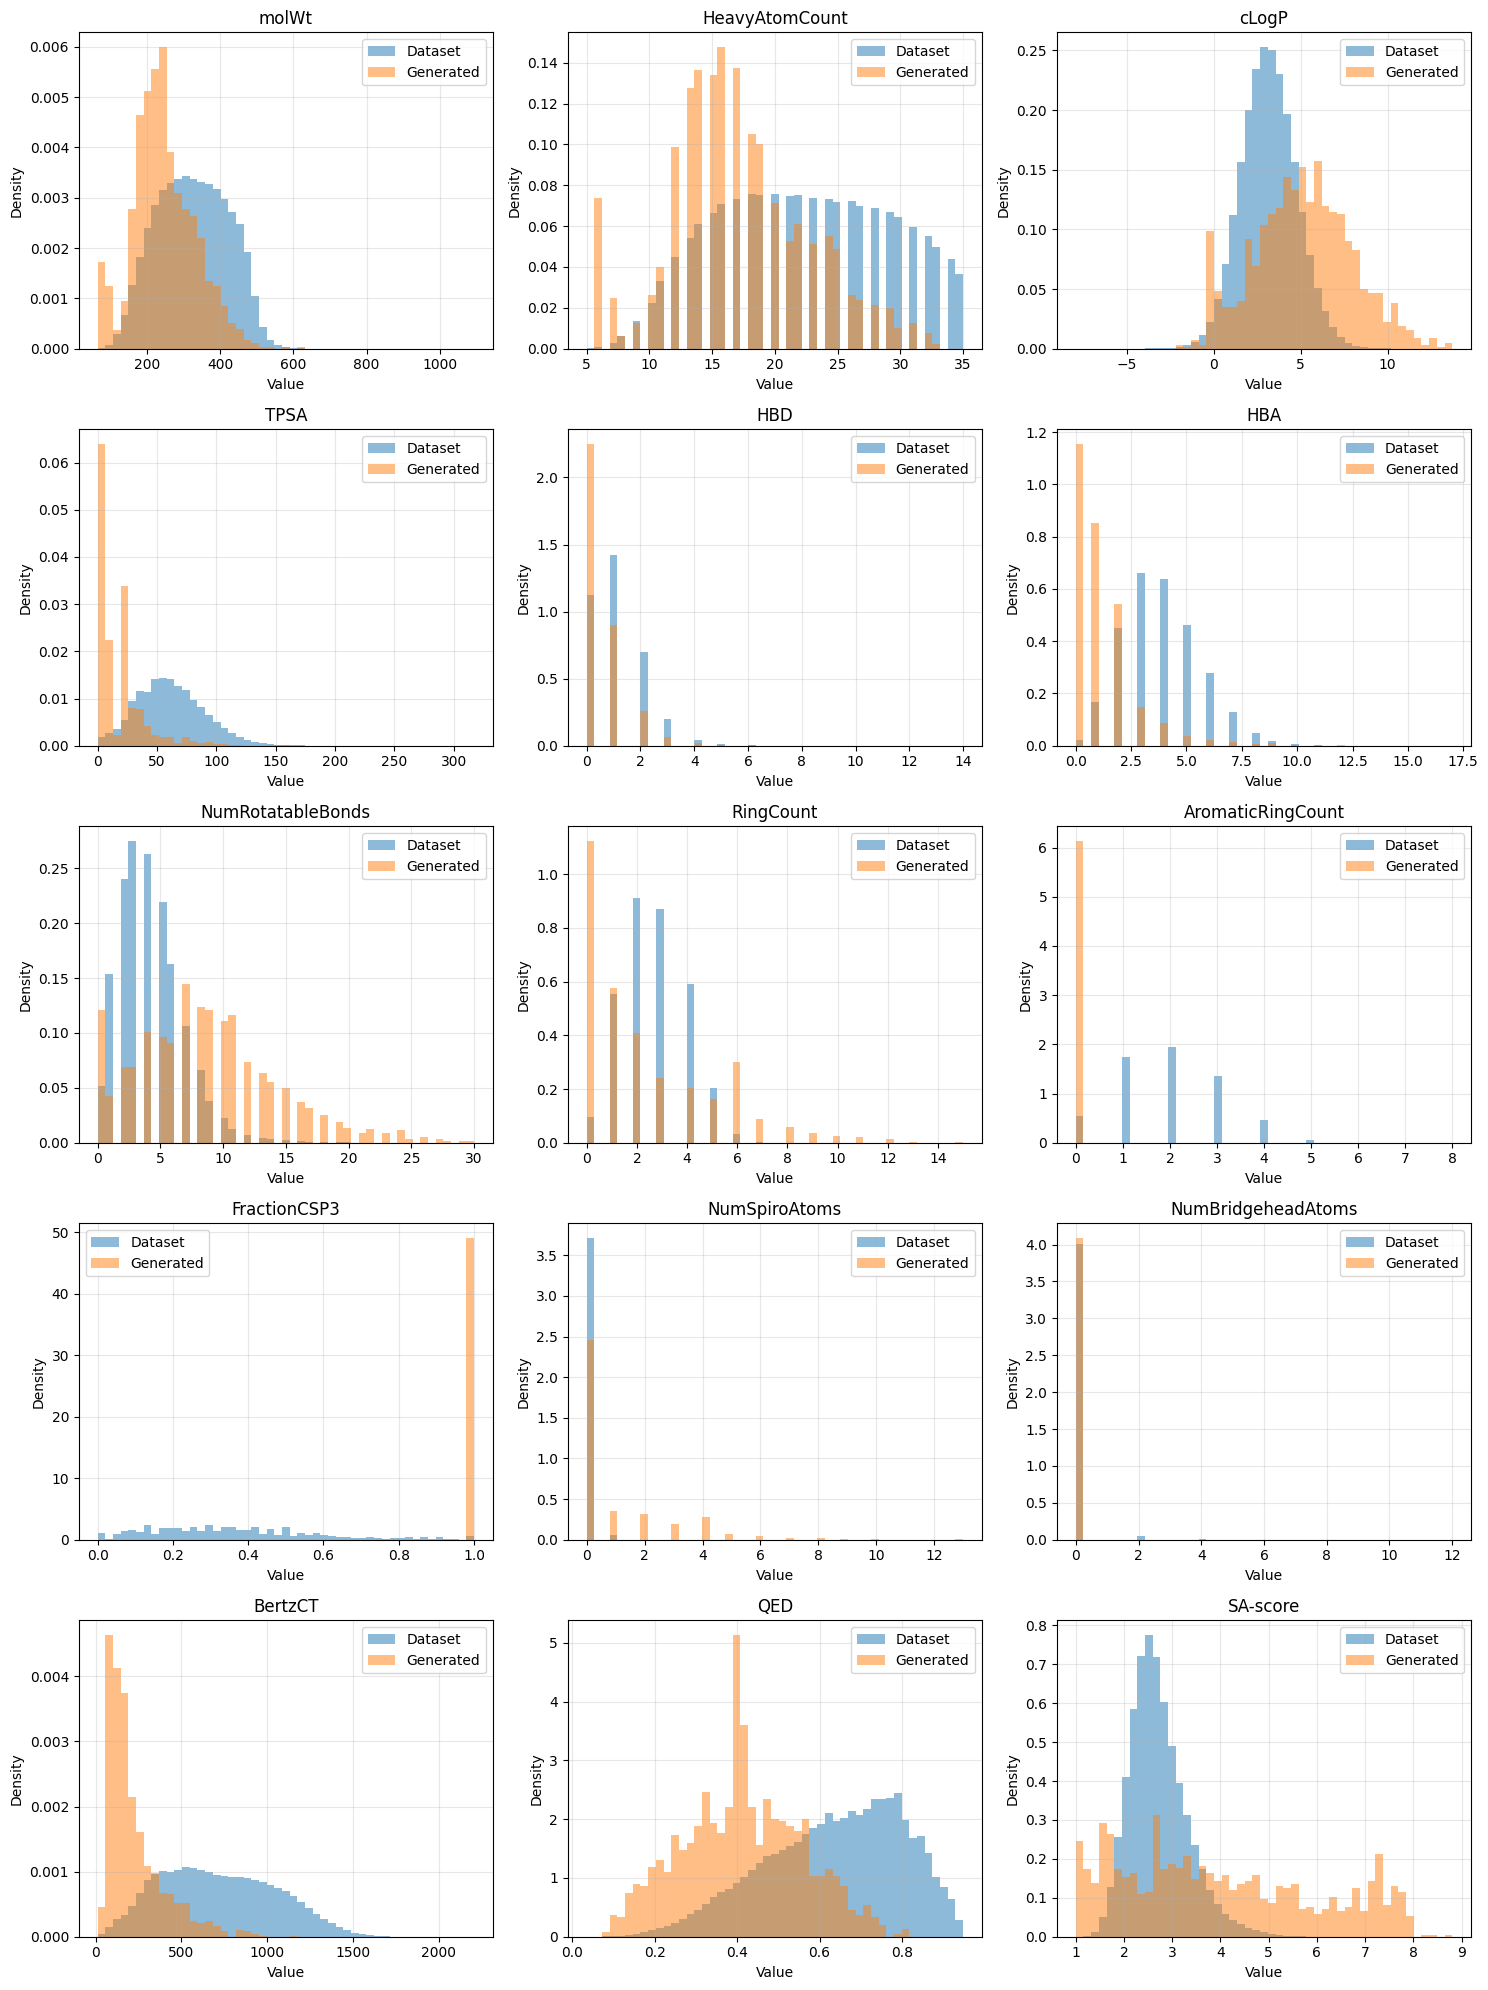

In [80]:

# plots
prop_dict = defaultdict(list)

for props in Sampled_properties:
    if props is None:
        continue
    for k, v in props.items():
        if v is not None and not np.isnan(v):
            prop_dict[k].append(v)

cols = Y.columns
n_cols = len(cols)

n_rows = math.ceil(n_cols / 3)
n_cols_grid = 3

fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(5 * n_cols_grid, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    gen_vals = prop_dict.get(col, [])

    if len(gen_vals) == 0:
        continue

    data_vals = Y[col].dropna()

    combined = np.concatenate([data_vals.values, gen_vals])
    bins = np.linspace(combined.min(), combined.max(), 50)

    axes[i].hist(data_vals, bins=bins, alpha=0.5, label="Dataset", density=True)
    axes[i].hist(gen_vals, bins=bins, alpha=0.5, label="Generated", density=True)

    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")
    axes[i].grid(alpha=0.3)
    axes[i].legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [35]:
print("Y shape:", Y.shape)
print("prop_dict keys:", prop_dict.keys())
print("Y columns:", Y.columns)

Y shape: (794403, 15)
prop_dict keys: dict_keys([])
Y columns: Index(['molWt', 'HeavyAtomCount', 'cLogP', 'TPSA', 'HBD', 'HBA',
       'NumRotatableBonds', 'RingCount', 'AromaticRingCount', 'FractionCSP3',
       'NumSpiroAtoms', 'NumBridgeheadAtoms', 'BertzCT', 'QED', 'SA-score'],
      dtype='str')


In [36]:
print("TOTAL MOLS:", len(mols))
print("VALID MOLS:", len(valid_mols))
print("VALIDITY:", len(valid_mols)/len(mols))

TOTAL MOLS: 10000
VALID MOLS: 9340
VALIDITY: 0.934


In [41]:
print("Sampled_properties len:", len(Sampled_properties))
print("first element:", Sampled_properties[0] if len(Sampled_properties) > 0 else None)

Sampled_properties len: 9340
first element: {'molWt': 216.40899999999993, 'HeavyAtomCount': 15, 'cLogP': 5.189800000000005, 'TPSA': 9.23, 'HBD': 0, 'HBA': 1, 'NumRotatableBonds': 9, 'RingCount': 0, 'AromaticRingCount': 0, 'FractionCSP3': 1.0, 'NumSpiroAtoms': 0, 'NumBridgeheadAtoms': 0, 'BertzCT': 71.40788563534187, 'QED': 0.4819053468921508, 'SA-score': 1.5674836885911425}


In [39]:
print("valid_mols:", len(valid_mols))

valid_mols: 9340


In [43]:
def compute_generation_metrics(mols, train_smiles_set):
    valid_mols = [m for m in mols if m is not None]

    # validity
    validity = len(valid_mols) / len(mols) if len(mols) > 0 else 0

    # convert to SMILES
    smiles = []
    for m in valid_mols:
        try:
            s = Chem.MolToSmiles(m, canonical=True)
            smiles.append(s)
        except:
            pass

    # uniqueness
    unique_smiles = set(smiles)
    uniqueness = len(unique_smiles) / len(smiles) if len(smiles) > 0 else 0

    # novelty (vs training set)
    novel_smiles = [s for s in unique_smiles if s not in train_smiles_set]
    novelty = len(novel_smiles) / len(unique_smiles) if len(unique_smiles) > 0 else 0

    return {
        "validity": validity,
        "uniqueness": uniqueness,
        "novelty": novelty,
        "n_valid": len(valid_mols),
        "n_unique": len(unique_smiles),
        "n_novel": len(novel_smiles),
    }

In [46]:
train_smiles_set = set(df["smiles"].dropna().tolist())
metrics = compute_generation_metrics(mols, train_smiles_set)

print("Validity:", metrics["validity"])
print("Uniqueness:", metrics["uniqueness"])
print("Novelty:", metrics["novelty"])
print("Valid:", metrics["n_valid"])
print("Unique:", metrics["n_unique"])
print("Novel:", metrics["n_novel"])

Validity: 0.934
Uniqueness: 0.3684154175588865
Novelty: 0.967451322290032
Valid: 9340
Unique: 3441
Novel: 3329
